# Exp3: Semigreedy v1 vs v2 vs v3 por iteracion

Este notebook carga los archivos consolidados `.iter` y genera:
- Grafica de promedio de valor objetivo por iteracion sobre todas las instancias
- Grafica de promedio de tiempo por iteracion sobre todas las instancias
- Grafica de numero de soluciones encontradas por iteracion sobre todas las instancias

Cada curva corresponde a una variante: `v1`, `v2` y `v3`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path(".")

v1_value_path = BASE_DIR / "semigreedy2s-v1-value.iter"
v2_value_path = BASE_DIR / "semigreedy2s-v2-value.iter"
v3_value_path = BASE_DIR / "semigreedy2s-v3-value.iter"
v1_time_path = BASE_DIR / "semigreedy2s-v1-time.iter"
v2_time_path = BASE_DIR / "semigreedy2s-v2-time.iter"
v3_time_path = BASE_DIR / "semigreedy2s-v3-time.iter"
v1_found_path = BASE_DIR / "semigreedy2s-v1-found.iter"
v2_found_path = BASE_DIR / "semigreedy2s-v2-found.iter"
v3_found_path = BASE_DIR / "semigreedy2s-v3-found.iter"

required = [
    v1_value_path, v2_value_path, v3_value_path,
    v1_time_path, v2_time_path, v3_time_path,
    v1_found_path, v2_found_path, v3_found_path,
]
missing = [p for p in required if not p.exists()]
if missing:
    missing_str = "\n".join(str(p) for p in missing)
    raise FileNotFoundError(
        "Faltan archivos consolidados. Primero ejecuta merge_semigreedy_iters.py.\n"
        f"Archivos faltantes:\n{missing_str}"
    )

def load_iter_df(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "iter" not in df.columns:
        raise ValueError(f"El archivo {path} no tiene columna 'iter'.")
    df = df.copy()
    df["iter"] = df["iter"].astype(int)
    return df.sort_values("iter")

def all_value_columns(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c != "iter"]

def mean_by_iter_all_instances(df: pd.DataFrame) -> pd.Series:
    cols = all_value_columns(df)
    s = df[cols].mean(axis=1, skipna=True)
    s.index = df["iter"]
    return s.sort_index()

def found_count_by_iter_all_instances(df: pd.DataFrame) -> pd.Series:
    cols = all_value_columns(df)
    # En found.iter: 1 = solucion encontrada, 0 = no encontrada.
    s = (df[cols] == 1).sum(axis=1)
    s.index = df["iter"]
    return s.sort_index()

v1_value_df = load_iter_df(v1_value_path)
v2_value_df = load_iter_df(v2_value_path)
v3_value_df = load_iter_df(v3_value_path)
v1_time_df = load_iter_df(v1_time_path)
v2_time_df = load_iter_df(v2_time_path)
v3_time_df = load_iter_df(v3_time_path)
v1_found_df = load_iter_df(v1_found_path)
v2_found_df = load_iter_df(v2_found_path)
v3_found_df = load_iter_df(v3_found_path)

v1_value_mean = mean_by_iter_all_instances(v1_value_df)
v2_value_mean = mean_by_iter_all_instances(v2_value_df)
v3_value_mean = mean_by_iter_all_instances(v3_value_df)
v1_time_mean = mean_by_iter_all_instances(v1_time_df)
v2_time_mean = mean_by_iter_all_instances(v2_time_df)
v3_time_mean = mean_by_iter_all_instances(v3_time_df)
v1_found_count = found_count_by_iter_all_instances(v1_found_df)
v2_found_count = found_count_by_iter_all_instances(v2_found_df)
v3_found_count = found_count_by_iter_all_instances(v3_found_df)

plt.style.use("seaborn-v0_8-whitegrid")

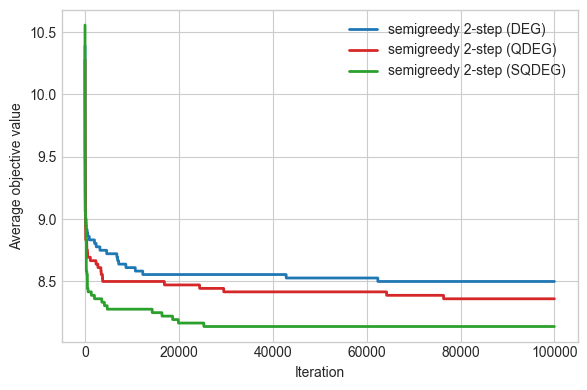

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(v1_value_mean.index, v1_value_mean.values, color="#1f77b4", linewidth=2, label="semigreedy 2-step (DEG)")
ax.plot(v2_value_mean.index, v2_value_mean.values, color="#d62728", linewidth=2, label="semigreedy 2-step (QDEG)")
ax.plot(v3_value_mean.index, v3_value_mean.values, color="#2ca02c", linewidth=2, label="semigreedy 2-step (SQDEG)")
# ax.set_title("Average best objective value")
ax.set_xlabel("Iteration")
ax.set_ylabel("Average objective value")
ax.legend()
plt.tight_layout()
plt.savefig("semigreedy_iters_value.png", dpi=300)
plt.show()

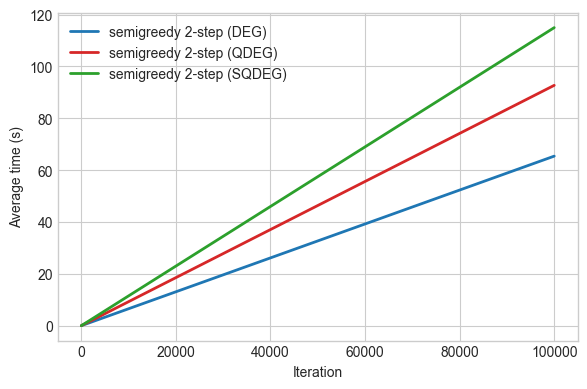

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(v1_time_mean.index, v1_time_mean.values, color="#1f77b4", linewidth=2, label="semigreedy 2-step (DEG)")
ax.plot(v2_time_mean.index, v2_time_mean.values, color="#d62728", linewidth=2, label="semigreedy 2-step (QDEG)")
ax.plot(v3_time_mean.index, v3_time_mean.values, color="#2ca02c", linewidth=2, label="semigreedy 2-step (SQDEG)")
# ax.set_title("Average cumulative execution time")
ax.set_xlabel("Iteration")
ax.set_ylabel("Average time (s)")
ax.legend()
plt.tight_layout()
plt.savefig("semigreedy_iters_time.png", dpi=300)
plt.show()

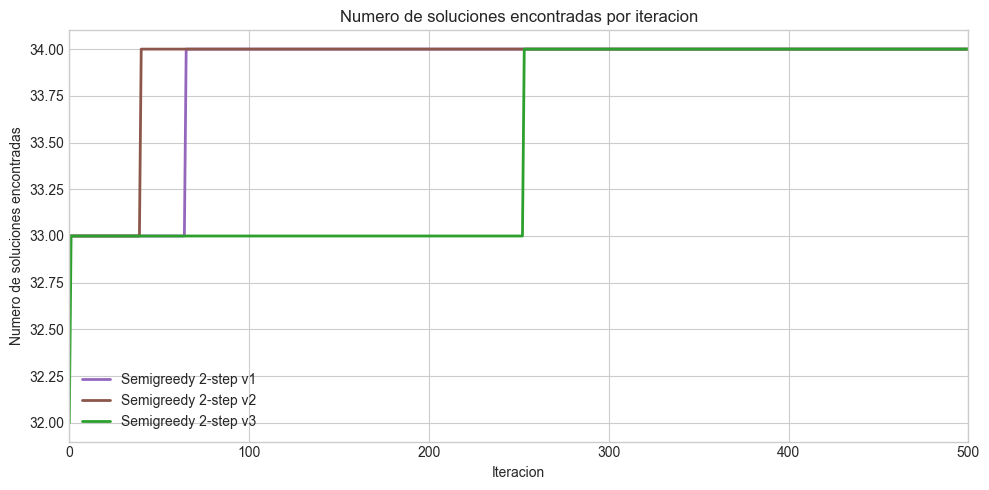

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(v1_found_count.index, v1_found_count.values, color="#9467bd", linewidth=2, label="Semigreedy 2-step v1")
ax.plot(v2_found_count.index, v2_found_count.values, color="#8c564b", linewidth=2, label="Semigreedy 2-step v2")
ax.plot(v3_found_count.index, v3_found_count.values, color="#2ca02c", linewidth=2, label="Semigreedy 2-step v3")
ax.set_title("Numero de soluciones encontradas por iteracion")
ax.set_xlabel("Iteracion")
ax.set_ylabel("Numero de soluciones encontradas")
ax.legend()
ax.set_xlim(0, 500)
plt.tight_layout()
plt.show()